<a href="https://colab.research.google.com/github/Sri1712/PDF_Data_Extraction/blob/main/pdf_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install libraries

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [4]:
# Core
%pip install pymupdf pymupdf4llm --quiet
%pip install jiwer python-Levenshtein --quiet
%pip install pandas openpyxl --quiet

# Open-source extractors
%pip install docling --quiet
'''%pip install unstructured[all-docs] --quiet
%pip install marker-pdf --quiet

# Commercial (need API keys)
%pip install llama-parse --quiet
%pip install azure-ai-documentintelligence --quiet
%pip install boto3 --quiet
%pip install mistralai --quiet '''

print("Libraries ready")

Libraries ready


## Imports and paths

In [15]:
import os, io, re, csv, time, json, warnings
import pandas as pd
from pathlib import Path
from PIL import Image
import fitz                        # PyMuPDF
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")

# ── PDF to analyse ────────────────────────────────────────────────
PDF_PATH = "/content/drive/MyDrive/github_projects/PDF_Data_Extraction/corpus/4_scanned_document.pdf"

# ── Output folder (everything saved here, visible in Drive) ───────
OUTPUT_BASE = "/content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs"

'''# ── API keys (use Colab Secrets panel 🔑 on the left sidebar) ─────
# Add each key in the Secrets panel, then load them here:
try:
    from google.colab import userdata
    LLAMA_KEY   = userdata.get("LLAMA_CLOUD_API_KEY") or ""
    MISTRAL_KEY = userdata.get("MISTRAL_API_KEY")     or ""
    AZURE_EP    = userdata.get("AZURE_DI_ENDPOINT")   or ""
    AZURE_KEY   = userdata.get("AZURE_DI_KEY")        or ""
except Exception:
    LLAMA_KEY = MISTRAL_KEY = AZURE_EP = AZURE_KEY = ""

'''

# ── Create output folders ─────────────────────────────────────────
pdf_path   = Path(PDF_PATH)
pdf_stem   = pdf_path.stem

GT_DIR = Path(OUTPUT_BASE) / "ground_truth" / pdf_stem
SCORES_DIR = Path(OUTPUT_BASE) / "scores"
IMGS_DIR = Path(OUTPUT_BASE) / "images"
TEXT_DIR = Path(OUTPUT_BASE) / "text"

for folder in [GT_DIR, SCORES_DIR, IMGS_DIR, TEXT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ── Quick PDF summary ─────────────────────────────────────────────
assert pdf_path.exists(), f"PDF not found: {pdf_path}"
doc = fitz.open(str(pdf_path))
n_pages      = doc.page_count
total_chars  = sum(len(p.get_text()) for p in doc)
total_images = sum(len(p.get_images()) for p in doc)
doc.close()

print(f"PDF      : {pdf_path.name}")
print(f"Pages    : {n_pages}")
print(f"Chars    : {total_chars:,}")
print(f"Images   : {total_images}")
print(f"Output   : {OUTPUT_BASE}")
#print()
#print(f"API keys loaded:")
#print(f"  LlamaParse : {'YES' if LLAMA_KEY   else 'not set'}")
#print(f"  Mistral    : {'YES' if MISTRAL_KEY else 'not set'}")
#print(f"  Azure DI   : {'YES' if AZURE_EP   else 'not set'}")

PDF      : 4_scanned_document.pdf
Pages    : 10
Chars    : 80
Images   : 10
Output   : /content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs


## Ground truth

In [16]:
# ── Choose which pages to use as ground truth ─────────────────────
GT_TEXT_PAGE  = 1    # page number for text evaluation (1-based)
#GT_TABLE_PAGE = 15   # page number for table evaluation (1-based)

# ── Auto-extract text from GT_TEXT_PAGE ───────────────────────────
doc   = fitz.open(str(pdf_path))
page  = doc[GT_TEXT_PAGE - 1]
pw    = page.rect.width

raw_blocks = page.get_text("blocks")   # (x0, y0, x1, y1, text, block_no, block_type)

# Two-column aware sort: detect if page has two columns
left_blocks  = [b for b in raw_blocks if b[0] < pw / 2]
right_blocks = [b for b in raw_blocks if b[0] >= pw / 2]
is_two_col   = len(left_blocks) > 2 and len(right_blocks) > 2

if is_two_col:
    sorted_blocks = (
        sorted(left_blocks,  key=lambda b: b[1]) +
        sorted(right_blocks, key=lambda b: b[1])
    )
else:
    sorted_blocks = sorted(raw_blocks, key=lambda b: (round(b[1]/20)*20, b[0]))

# Deduplicate
seen, clean_blocks = set(), []
for b in sorted_blocks:
    txt = re.sub(r"\s+", " ", b[4]).strip()
    if txt and txt.lower() not in seen:
        seen.add(txt.lower())
        clean_blocks.append(b)

gt_text_draft = "".join(b[4].strip() for b in clean_blocks if b[4].strip())
doc.close()

# Save text ground truth
gt_text_path = GT_DIR / f"gt_text_page{GT_TEXT_PAGE}.md"
gt_text_path.write_text(gt_text_draft, encoding="utf-8")

print(f"Text ground truth saved to Drive:")
print(f"  {gt_text_path}")
print(f"Preview (first 800 chars):")
print("-" * 50)
print(gt_text_draft[:800])
print("-" * 50)

Text ground truth saved to Drive:
  /content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs/ground_truth/4_scanned_document/gt_text_page1.md
Preview (first 800 chars):
--------------------------------------------------
EXAMPLE
--------------------------------------------------


In [ ]:
# ── Auto-extract table from GT_TABLE_PAGE ─────────────────────────
doc   = fitz.open(str(pdf_path))
page  = doc[GT_TABLE_PAGE - 1]

tables_found = page.find_tables()
doc.close()

gt_table_path = GT_DIR / f"gt_table_page{GT_TABLE_PAGE}.csv"

if tables_found:
    # Take the largest table on the page
    biggest = max(tables_found, key=lambda t: len(t.extract()) * len(t.extract()[0]) if t.extract() else 0)
    raw_rows = biggest.extract()
    gt_table_draft = [[c if c else "" for c in row] for row in raw_rows]

    with open(gt_table_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerows(gt_table_draft)

    print(f"Table ground truth auto-extracted ({len(gt_table_draft)} rows).")
    print(f"Saved to Drive: {gt_table_path}")
    print(f"Preview:")
    print(pd.DataFrame(gt_table_draft).to_string(index=False, header=False))

else:
    # No table detected — write a blank template
    print("No table auto-detected on this page.")
    print("Writing a blank template — fill it in manually in Google Drive.")
    gt_table_draft = [
        ["Column 1", "Column 2", "Column 3", "Column 4", "Column 5"],
        ["", "", "", "", ""],
        ["", "", "", "", ""],
    ]
    with open(gt_table_path, "w", newline="", encoding="utf-8") as f:
        csv.writer(f).writerows(gt_table_draft)
    print(f"Blank template saved to: {gt_table_path}")


Table ground truth auto-extracted (8 rows).
Saved to Drive: /content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs/ground_truth/1_Rapport-financier-semestriel-AFD-2025/gt_table_page15.csv
Preview:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              Liabilities                                                                                                                                                                                                                                                              

In [7]:
# Load ground truth from Drive
def load_gt_text():
    p = GT_DIR / f"gt_text_page{GT_TEXT_PAGE}.md"
    return p.read_text(encoding="utf-8").strip() if p.exists() else ""

'''def load_gt_table():
    p = GT_DIR / f"gt_table_page{GT_TABLE_PAGE}.csv"
    if not p.exists():
        return []
    with open(p, newline="", encoding="utf-8") as f:
        return list(csv.reader(f))'''

GT_TEXT  = load_gt_text()
#GT_TABLE = load_gt_table()

print(f"Ground truth text  : {len(GT_TEXT)} chars loaded")
#print(f"Ground truth table : {len(GT_TABLE)} rows loaded")


Ground truth text  : 3802 chars loaded


## Scoring functions (CER + TEDS)

In [13]:
from jiwer import cer as jiwer_cer
import Levenshtein

ALL_SCORES = []   # collects one row per tool

def compute_cer(extracted: str, reference: str) -> float:
    "Character Error Rate — 0.0 = perfect, lower is better."
    ref = re.sub(r"\s+", " ", reference.strip())
    hyp = re.sub(r"\s+", " ", extracted.strip())
    if not ref:
        return 0.0
    return round(jiwer_cer(ref, hyp), 4)

def compute_teds(pred: list, gt: list) -> float:
    "Table similarity — 1.0 = perfect, higher is better."
    if not gt:   return 1.0
    if not pred: return 0.0
    def to_str(tbl):
        return "(table " + "".join(
            "(tr " + "".join(f"(td {str(c).strip()})" for c in row) + ")"
            for row in tbl
        ) + ")"
    s1, s2 = to_str(pred), to_str(gt)
    return round(1 - Levenshtein.distance(s1, s2) / max(len(s1), len(s2)), 4)

def stars(val, metric):
    if metric == "cer":
        thresholds = [(0.05,5),(0.10,4),(0.20,3),(0.40,2)]
    else:
        thresholds = [(0.95,5),(0.85,4),(0.70,3),(0.50,2)]
    for t, s in thresholds:
        if (val <= t if metric=="cer" else val >= t):
            return "★" * s + "☆" * (5 - s)
    return "★☆☆☆☆"

def show_scores(tool_name, text, table, elapsed, cost_note="free"):
    GT_TEXT  = load_gt_text()    # always reload in case file was edited
    #GT_TABLE = load_gt_table()

    cer  = compute_cer(text, GT_TEXT)   if GT_TEXT  else None
    #teds = compute_teds(table, GT_TABLE) if GT_TABLE else None

    print()
    print("┌" + "─" * 53 + "┐")
    print(f"│  SCORES — {tool_name:<42}│")
    print("├" + "─" * 53 + "┤")
    if cer  is not None:
        print(f"│  CER  (text)  : {cer:.4f}   {stars(cer,'cer'):<15}        │")
    #if teds is not None:
        #print(f"│  TEDS (table) : {teds:.4f}   {stars(teds,'teds'):<15}        │")
    print(f"│  Time         : {elapsed:.1f}s{' '*38}│")
    print(f"│  Cost         : {cost_note:<37}│")
    print("└" + "─" * 53 + "┘")
    print("  CER:  0.0=perfect · <0.10=good · >0.30=poor")
    #print("  TEDS: 1.0=perfect · >0.85=good · <0.50=poor")

    row = {
        "tool"   : tool_name,
        "CER"    : cer  if cer  is not None else "N/A",
        #"TEDS"   : teds if teds is not None else "N/A",
        "time_s" : round(elapsed, 1),
        "cost"   : cost_note,
    }
    ALL_SCORES.append(row)

    # Save individual score to Drive
    score_path = SCORES_DIR / f"{tool_name.replace(' ','_')}_scores.json"
    with open(score_path, "w") as f:
        json.dump(row, f, indent=2)

print("Scoring functions ready.")
print(f"Individual score files will be saved to: {SCORES_DIR}")


Scoring functions ready.
Individual score files will be saved to: /content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs/scores


In [ ]:
from jiwer import cer as jiwer_cer
import Levenshtein

# ── CER ───────────────────────────────────────────────────────────
def compute_cer(extracted_text: str, reference_text: str) -> float:
    """Character Error Rate. 0.0 = perfect. Lower is better."""
    ref = re.sub(r"\s+", " ", reference_text.strip())
    hyp = re.sub(r"\s+", " ", extracted_text.strip())
    if not ref:
        return 0.0
    return round(jiwer_cer(ref, hyp), 4)

# ── TEDS ──────────────────────────────────────────────────────────
def compute_teds(pred_table: list, gt_table: list) -> float:
    """Table similarity 0.0–1.0. 1.0 = perfect match. Higher is better."""
    if not gt_table:
        return 1.0
    if not pred_table:
        return 0.0
    # Linearise tables as bracketed strings then compare edit distance
    def to_string(table):
        rows = []
        for row in table:
            cells = "".join(f"(td {str(c).strip()})" for c in row)
            rows.append(f"(tr {cells})")
        return f"(table {''.join(rows)})"
    s1 = to_string(pred_table)
    s2 = to_string(gt_table)
    dist = Levenshtein.distance(s1, s2)
    return round(1.0 - dist / max(len(s1), len(s2)), 4)

# ── Score display ─────────────────────────────────────────────────
def show_scores(tool_name, extracted_text, extracted_table, elapsed):
    cer  = compute_cer(extracted_text, GT_TEXT)
    teds = compute_teds(extracted_table, GT_TABLE)

    # CER to star rating
    if cer <= 0.05:   cer_stars  = 5.0
    elif cer <= 0.10: cer_stars  = 4.0
    elif cer <= 0.20: cer_stars  = 3.0
    elif cer <= 0.40: cer_stars  = 2.0
    else:             cer_stars  = 1.0

    # TEDS to star rating
    if teds >= 0.95:   teds_stars = 5.0
    elif teds >= 0.85: teds_stars = 4.0
    elif teds >= 0.70: teds_stars = 3.0
    elif teds >= 0.50: teds_stars = 2.0
    else:              teds_stars = 1.0

    print("=" * 55)
    print(f"  SCORES FOR: {tool_name}")
    print("=" * 55)
    print(f"  CER  (text accuracy)  : {cer:.4f}  {cer_stars}")
    print(f"  TEDS (table accuracy) : {teds:.4f}  {teds_stars}")
    print(f"  Time                  : {elapsed:.1f}s")
    print(f"  CER note : 0.0 = perfect | <0.10 = good | >0.30 = poor")
    print(f"  TEDS note: 1.0 = perfect | >0.85 = good | <0.50 = poor")
    print("=" * 55)
    return {"tool": tool_name, "CER": cer, "TEDS": teds, "time_s": round(elapsed,1)}

# Collect all results here
ALL_SCORES = []
print("Scoring functions ready.")


Scoring functions ready.


## Tool 1 · PyMuPDF4LLM
**Licence:** AGPL / commercial  
**Best for:** Fast baseline, native PDF text, no ML required  

In [23]:
import fitz
import pymupdf4llm

t0 = time.perf_counter()

# ── Text ──────────────────────────────────────────────────────────
pymupdf_text = pymupdf4llm.to_markdown(str(pdf_path))

# ── Tables ────────────────────────────────────────────────────────
doc = fitz.open(str(pdf_path))
pymupdf_tables = []
for page in doc:
    for tbl in page.find_tables():
        rows = tbl.extract()
        clean = [[c if c else "" for c in row] for row in rows]
        pymupdf_tables.append(clean)

# ── Images ────────────────────────────────────────────────────────
img_out  = IMGS_DIR / "pymupdf4llm"
img_out.mkdir(parents=True, exist_ok=True)
saved_imgs = []
for pg_i, page in enumerate(doc):
    for im_i, img_info in enumerate(page.get_images(full=True)):
        xref = img_info[0]
        base = doc.extract_image(xref)
        dest = img_out / f"page{pg_i+1}_img{im_i+1}.{base['ext']}"
        dest.write_bytes(base["image"])
        saved_imgs.append(str(dest))
doc.close()

elapsed_pymupdf = time.perf_counter() - t0

tool_text_dir = Path(OUTPUT_BASE) / "pymupdf4llm" / pdf_stem
tool_text_dir.mkdir(parents=True, exist_ok=True)
(tool_text_dir / "page_1.md").write_text(pymupdf_text, encoding="utf-8")

# ── Preview ───────────────────────────────────────────────────────
print(f"Time     : {elapsed_pymupdf:.1f}s")
print(f"Tables   : {len(pymupdf_tables)}")
print(f"Images   : {len(saved_imgs)}")
print()
print("── Text preview (first 600 chars) ──")
print(pymupdf_text[:600])

=== Document parser messages ===
                                                                                                                                                                                                                                                                                                Using Tesseract for OCR processing.
Using Tesseract for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=2/3.
OCR on page.number=3/4.
OCR on page.number=4/5.
OCR on page.number=5/6.
OCR on page.number=6/7.
Using Tesseract for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=2/3.
OCR on page.number=3/4.
OCR on page.number=4/5.
OCR on page.number=5/6.
OCR on page.number=6/7.
OCR on page.number=7/8.
OCR on page.number=8/9.

Time     : 47.9s
Tables   : 0
Images   : 10

── Text preview (first 600 chars) ──
**==> picture [497 x 278] intentionally omitted <==**

**----- Start of picture text -----**<br>
Please 

In [18]:
# ── Tables preview ────────────────────────────────────────────────
if pymupdf_tables:
    print(f"First table ({len(pymupdf_tables[0])} rows):")
    print(pd.DataFrame(pymupdf_tables[0]).to_string(index=False, header=False))
else:
    print("No tables extracted.")

No tables extracted.


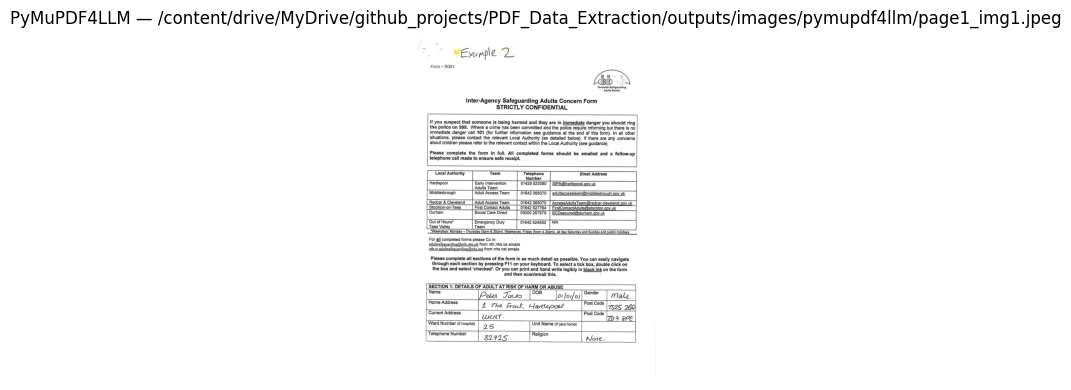

In [24]:
# ── Images preview ────────────────────────────────────────────────
if saved_imgs:
    img = Image.open(saved_imgs[0])
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"PyMuPDF4LLM — {saved_imgs[0]}")
    plt.tight_layout()
    plt.show()
else:
    print("No images found in this PDF.")

In [25]:
# ── SCORES ────────────────────────────────────────────────────────
pred_table_pymupdf = pymupdf_tables[0] if pymupdf_tables else []
scores = show_scores("PyMuPDF4LLM", md_text, pred_table_pymupdf, elapsed_pymupdf)
ALL_SCORES.append(scores)


┌─────────────────────────────────────────────────────┐
│  SCORES — PyMuPDF4LLM                               │
├─────────────────────────────────────────────────────┤
│  CER  (text)  : 1298.1429   ★☆☆☆☆                  │
│  Time         : 47.9s                                      │
│  Cost         : free                                 │
└─────────────────────────────────────────────────────┘
  CER:  0.0=perfect · <0.10=good · >0.30=poor


## Tool 2 · Docling
**Licence:** MIT (IBM)  
**Best for:** Best table structure, heading detection, multi-column layout  

In [ ]:
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

opts = PdfPipelineOptions()
opts.do_ocr             = True
opts.do_table_structure = True

converter = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=opts)}
)

t0     = time.perf_counter()
result = converter.convert(str(pdf_path))
doc_dl = result.document

# ── Text ──────────────────────────────────────────────────────────
docling_text  = doc_dl.export_to_markdown()
docling_plain = doc_dl.export_to_text()

# ── Tables ────────────────────────────────────────────────────────
docling_tables = []
for tbl_item in doc_dl.tables:
    df = tbl_item.export_to_dataframe(doc=doc_dl)
    docling_tables.append(df.values.tolist())

# ── Figures ───────────────────────────────────────────────────────
fig_out = IMGS_DIR / "docling"
fig_out.mkdir(parents=True, exist_ok=True)
saved_imgs = []
for i, fig in enumerate(getattr(doc_dl, "pictures", [])):
    try:
        img_bytes = fig.image.as_bytes()
        dest = fig_out / f"figure_{i+1}.png"
        dest.write_bytes(img_bytes)
        saved_imgs.append(str(dest))
    except Exception:
        pass

elapsed_docling = time.perf_counter() - t0

# Save text
tool_text_dir = Path(OUTPUT_BASE) / "docling" / pdf_stem
tool_text_dir.mkdir(parents=True, exist_ok=True)

# Save each page separately
pages = docling_text.split("\f")
if len(pages) <= 1:
    pages = [docling_text]

for pg_i, page_text in enumerate(pages, start=1):
    if page_text.strip():
        page_file = tool_text_dir / f"page_{pg_i}.md"
        page_file.write_text(page_text.strip(), encoding="utf-8")

print(f"Time    : {elapsed_docling:.1f}s")
print(f"Tables  : {len(docling_tables)}")
print(f"Figures : {len(saved_imgs)} saved → {fig_out}")
print(f"Text    : {len(pages)} page file(s) saved → {tool_text_dir}")
print()
print("── Text preview ──")
print(docling_text[:600])

[INFO] 2026-05-31 11:11:03,094 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-31 11:11:03,099 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-31 11:11:03,099 [RapidOCR] main.py:57: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-31 11:11:03,171 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-31 11:11:03,173 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-05-31 11:11:03,173 [RapidOCR] main.py:57: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-05-31 11:11:03,208 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-31 11:11:03,216 [RapidOCR] download_file.py:60: File exists and is valid: /usr

Time    : 188.0s
Tables  : 58
Figures : 0 saved → /content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs/images/docling
Text    : 1 page file(s) saved → /content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs/docling/1_Rapport-financier-semestriel-AFD-2025

── Text preview ──
<!-- image -->

## Half-year financial report 30 June 2025

## Contents

| A.                                                                                                                                                                                                                                                 | Management report............................................................................................................................4            |
|---------------------------------------------------------------------------------------------------------------------------


In [ ]:
# ── Table preview ─────────────────────────────────────────────────
if docling_tables:
    print(f"First table ({len(docling_tables[0])} rows):")
    print(pd.DataFrame(docling_tables[0]).to_string(index=False, header=False))
else:
    print("No tables extracted.")

First table (28 rows):
                                                                                                                                                                                                                                                A.            Management report............................................................................................................................4
                                                                                                   1. AFD Group activities.......................................................................................................................4                                                                                                                                                          
                                                                                                          2. Recent changes and outlook................................................

In [ ]:
# ── Image preview ─────────────────────────────────────────────────
if saved_imgs:
    img = Image.open(saved_imgs[0])
    plt.figure(figsize=(6, 4))
    plt.imshow(img); plt.axis("off")
    plt.title("Docling — first figure extracted")
    plt.tight_layout(); plt.show()
else:
    print("No figures extracted (vector charts won't appear as raster images).")

No figures extracted (vector charts won't appear as raster images).


In [ ]:
# ── SCORES ────────────────────────────────────────────────────────
pred_tbl_docling = docling_tables[0] if docling_tables else []
show_scores("Docling", docling_plain, pred_tbl_docling, elapsed_docling)



┌─────────────────────────────────────────────────────┐
│  SCORES — Docling                                   │
├─────────────────────────────────────────────────────┤
│  CER  (text)  : 39.9685   ★☆☆☆☆                  │
│  TEDS (table) : 0.1106   ★☆☆☆☆                  │
│  Time         : 188.0s                                      │
│  Cost         : free                                 │
└─────────────────────────────────────────────────────┘
  CER:  0.0=perfect · <0.10=good · >0.30=poor
  TEDS: 1.0=perfect · >0.85=good · <0.50=poor


## Tool 3 · Unstructured
**Licence:** Apache 2.0  
**Best for:** Element classification (titles, lists, tables, images), clean licence  

In [ ]:
from unstructured.partition.pdf import partition_pdf

t0       = time.perf_counter()
elements = partition_pdf(
    filename=str(pdf_path),
    strategy="fast",           # switch to "hi_res" for better accuracy
    languages=["eng", "fra"],
)

# ── Text ──────────────────────────────────────────────────────────
parts = []
for el in elements:
    txt     = str(el).strip()
    el_type = type(el).__name__
    if not txt: continue
    if el_type == "Title":        parts.append(f"## {txt}")
    elif el_type == "ListItem":   parts.append(f"- {txt}")
    else:                          parts.append(txt)

unstr_text = " ".join(parts)

# ── Tables ────────────────────────────────────────────────────────
unstr_tables = []
for el in elements:
    if type(el).__name__ == "Table":
        html = getattr(el.metadata, "text_as_html", None)
        if html:
            try:
                for df in pd.read_html(html):
                    unstr_tables.append(df.astype(str).values.tolist())
            except Exception:
                pass

# ── Images ────────────────────────────────────────────────────────
img_out = IMGS_DIR / "unstructured"
img_out.mkdir(parents=True, exist_ok=True)
saved_imgs = []
for el in elements:
    if type(el).__name__ == "Image":
        img_bytes = getattr(el.metadata, "image_bytes", None)
        if img_bytes:
            dest = img_out / f"img_{len(saved_imgs)+1}.png"
            dest.write_bytes(img_bytes)
            saved_imgs.append(str(dest))

elapsed_unstr = time.perf_counter() - t0

tool_text_dir = Path(OUTPUT_BASE) / "unstructured" / pdf_stem
tool_text_dir.mkdir(parents=True, exist_ok=True)
(tool_text_dir / "text.md").write_text(unstr_text, encoding="utf-8")

print(f"Time     : {elapsed_unstr:.1f}s")
print(f"Elements : {len(elements)}")
print(f"Tables   : {len(unstr_tables)}")
print(f"Images   : {len(saved_imgs)} saved to Drive → {img_out}")
print()
print("── Text preview ──")
print(unstr_text[:600])


Time     : 13.8s
Elements : 3177
Tables   : 0
Images   : 0 saved to Drive → /content/drive/MyDrive/github_projects/PDF_Data_Extraction/outputs/images/unstructured

── Text preview ──
## Half-year financial report 30 June 2025 AFD – 2025 half-year financial report ## Contents A. Management report ............................................................................................................................ 4 - 1. AFD Group activities ....................................................................................................................... 4 - 2. Recent changes and outlook .......................................................................................................... 6 2.1. Crises in several countries .....................................


In [ ]:
if unstr_tables:
    print(f"First table ({len(unstr_tables[0])} rows):")
    print(pd.DataFrame(unstr_tables[0]).to_string(index=False, header=False))
else:
    print("No tables extracted.")

No tables extracted.


In [ ]:
if saved_imgs:
    img = Image.open(saved_imgs[0])
    plt.figure(figsize=(6, 4))
    plt.imshow(img); plt.axis("off")
    plt.title("Unstructured — first image")
    plt.tight_layout(); plt.show()
else:
    print("No images found.")

No images found.


In [ ]:
pred_tbl_unstr = unstr_tables[0] if unstr_tables else []
show_scores("Unstructured", unstr_text, pred_tbl_unstr, elapsed_unstr)


┌─────────────────────────────────────────────────────┐
│  SCORES — Unstructured                              │
├─────────────────────────────────────────────────────┤
│  CER  (text)  : 35.5910   ★☆☆☆☆                  │
│  TEDS (table) : 0.0000   ★☆☆☆☆                  │
│  Time         : 13.8s                                      │
│  Cost         : free                                 │
└─────────────────────────────────────────────────────┘
  CER:  0.0=perfect · <0.10=good · >0.30=poor
  TEDS: 1.0=perfect · >0.85=good · <0.50=poor
